In [1]:
import sys 
from pathlib import Path
import torch
import os
import dill
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import os
from pathlib import Path
import cv2
import time

# sys.path.append("/home/franka_deoxys/diffusion_policy")
# from diffusion_policy.workspace.base_workspace import BaseWorkspace
# from diffusion_policy.model.common.rotation_transformer import RotationTransformer
# from diffusion_policy.common.pytorch_util import dict_apply
# from diffusion_policy.workspace.train_diffusion_unet_hybrid_workspace import TrainDiffusionUnetHybridWorkspace


sys.path.append("/home/franka_deoxys/deoxys_control/deoxys")
from deoxys import config_root
from deoxys.franka_interface import FrankaInterface
from deoxys.utils import  YamlConfig
from deoxys.utils.config_utils import robot_config_parse_args
from deoxys.utils.input_utils import input2action
from deoxys.utils.io_devices import SpaceMouse
from deoxys.utils.log_utils import get_deoxys_example_logger
from deoxys.experimental.motion_utils import follow_joint_traj, reset_joints_to


from deoxys_vision.networking.camera_redis_interface import CameraRedisSubInterface
from deoxys_vision.utils.camera_utils import assert_camera_ref_convention, get_camera_info


from util_eval import RobotStateRawObsDictGenerator, FrameStackForTrans




# ruff: noqa

import contextlib
import dataclasses
import datetime
import faulthandler
import os
import signal
import time
# from moviepy.editor import ImageSequenceClip
import numpy as np

import sys 
sys.path.append("/home/franka_deoxys/openpi/packages/openpi-client/src")


from openpi_client import image_tools
from openpi_client import websocket_client_policy
import pandas as pd
from PIL import Image
# from droid.robot_env import RobotEnv
import tqdm
import tyro

sys.path.append("/home/franka_deoxys/openpi/src")

# from openpi.policies import droid_policy
from openpi.policies import franka_policy

faulthandler.enable()

# DROID data collection frequency -- we slow down execution to match this frequency
DROID_CONTROL_FREQUENCY = 15


 

np.set_printoptions(precision=3, suppress=True)

logger = get_deoxys_example_logger()

pybullet build time: Sep 21 2024 19:35:50
/home/franka_deoxys/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
@dataclasses.dataclass
class Args:
    # Hardware parameters
    left_camera_id: str = "<your_camera_id>"  # e.g., "24259877"
    right_camera_id: str = "<your_camera_id>"  # e.g., "24514023"
    wrist_camera_id: str = "<your_camera_id>"  # e.g., "13062452"

    # Policy parameters
    external_camera: str | None = (
        None  # which external camera should be fed to the policy, choose from ["left", "right"]
    )

    # Rollout parameters
    max_timesteps: int = 600
    # How many actions to execute from a predicted action chunk before querying policy server again
    # 8 is usually a good default (equals 0.5 seconds of action execution).
    open_loop_horizon: int = 8

    # Remote server parameters
    # remote_host: str = "0.0.0.0"  # point this to the IP address of the policy server, e.g., "192.168.1.100"
    # remote_host: str = "192.168.1.96" 
    # remote_host: str = "132.177.8.84"
    remote_host: str = "132.177.8.86"
    remote_port: int = (
        8000  # point this to the port of the policy server, default server port for openpi servers is 8000
    )

# We are using Ctrl+C to optionally terminate rollouts early -- however, if we press Ctrl+C while the policy server is
# waiting for a new action chunk, it will raise an exception and the server connection dies.
# This context manager temporarily prevents Ctrl+C and delays it after the server call is complete.
@contextlib.contextmanager
def prevent_keyboard_interrupt():
    """Temporarily prevent keyboard interrupts by delaying them until after the protected code."""
    interrupted = False
    original_handler = signal.getsignal(signal.SIGINT)

    def handler(signum, frame):
        nonlocal interrupted
        interrupted = True

    signal.signal(signal.SIGINT, handler)
    try:
        yield
    finally:
        signal.signal(signal.SIGINT, original_handler)
        if interrupted:
            raise KeyboardInterrupt

def _extract_observation(args: Args, obs_dict, *, save_to_disk=False):
    image_observations = obs_dict["image"]
    left_image, right_image, wrist_image = None, None, None
    for key in image_observations:
        # Note the "left" below refers to the left camera in the stereo pair.
        # The model is only trained on left stereo cams, so we only feed those.
        if args.left_camera_id in key and "left" in key:
            left_image = image_observations[key]
        elif args.right_camera_id in key and "left" in key:
            right_image = image_observations[key]
        elif args.wrist_camera_id in key and "left" in key:
            wrist_image = image_observations[key]

    # Drop the alpha dimension
    left_image = left_image[..., :3]
    right_image = right_image[..., :3]
    wrist_image = wrist_image[..., :3]

    # Convert to RGB
    left_image = left_image[..., ::-1]
    right_image = right_image[..., ::-1]
    wrist_image = wrist_image[..., ::-1]

    # In addition to image observations, also capture the proprioceptive state
    robot_state = obs_dict["robot_state"]
    cartesian_position = np.array(robot_state["cartesian_position"])
    joint_position = np.array(robot_state["joint_positions"])
    gripper_position = np.array([robot_state["gripper_position"]])

    # Save the images to disk so that they can be viewed live while the robot is running
    # Create one combined image to make live viewing easy
    if save_to_disk:
        combined_image = np.concatenate([left_image, wrist_image, right_image], axis=1)
        combined_image = Image.fromarray(combined_image)
        combined_image.save("robot_camera_views.png")

    return {
        "left_image": left_image,
        "right_image": right_image,
        "wrist_image": wrist_image,
        "cartesian_position": cartesian_position,
        "joint_position": joint_position,
        "gripper_position": gripper_position,
    }

In [3]:
args=Args()

In [4]:
# Connect to the policy server
policy_client = websocket_client_policy.WebsocketClientPolicy(args.remote_host, args.remote_port)



In [5]:
# instruction = input("Enter instruction: ")
instruction = "pick up"

# Rollout parameters
actions_from_chunk_completed = 0
pred_action_chunk = None

In [6]:
request_data = franka_policy.make_franka_example()
request_data['prompt'] = instruction
request_data.keys()

for key in request_data.keys():
    if key not in ["prompt"]:
        print(f"key={key} shape={request_data[key].shape} dtype={request_data[key].dtype}")

key=observation/image shape=(120, 160, 3) dtype=uint8
key=observation/wrist_image shape=(120, 160, 3) dtype=uint8
key=observation/joint_position shape=(7,) dtype=float64
key=observation/gripper_position shape=(1,) dtype=float64


In [7]:
# Wrap the server call in a context manager to prevent Ctrl+C from interrupting it
# Ctrl+C will be handled after the server call is complete
with prevent_keyboard_interrupt():
    # this returns action chunk [10, 8] of 10 joint velocity actions (7) + gripper position (1)
    pred_action_chunk = policy_client.infer(request_data)["actions"]

In [8]:
pred_action_chunk.shape

(10, 7)

In [9]:
print("0:", pred_action_chunk[0] ) 
print("1:", pred_action_chunk[1] )
print("2:", pred_action_chunk[2] )
print("3:", pred_action_chunk[3] )

0: [ 0.055  1.095  0.435  2.588  0.466 -2.026 -0.217]
1: [ 0.055  1.095  0.435  2.588  0.466 -2.026 -0.217]
2: [ 0.055  1.095  0.435  2.588  0.466 -2.026 -0.217]
3: [ 0.055  1.095  0.435  2.588  0.466 -2.026 -0.217]


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [11]:
args = robot_config_parse_args()
robot_interface = FrankaInterface(os.path.join(config_root, args.interface_cfg))
controller_cfg = YamlConfig(
    os.path.join(config_root, args.controller_cfg)
).as_easydict()
controller_type = args.controller_type

# spacemouse = SpaceMouse(vendor_id=9583, product_id=50734) 
#old spacemoue not wireless
# spacemouse = SpaceMouse(vendor_id=9583, product_id=50770)
# spacemouse.start_control()
raw_obs_dict_generator = RobotStateRawObsDictGenerator()

In [12]:
def set_gripper(open=True):
    d=-1. if open else 1.0
    action_close=np.array([ 0.,  0., -0.,  0.,  0., -0., d])
    robot_interface.control(
        controller_type=controller_type,
        action=action_close,
        controller_cfg=controller_cfg,
    )

### reset robot position (no need to do it from terminal)

In [13]:
# copied from reset_robot_joints.py
# Golden resetting joints
reset_joint_positions = [
    0.09162008114028396,
    -0.19826458111314524,
    -0.01990020486871322,
    -2.4732269941140346,
    -0.01307073642274261,
    2.30396583422025,
    0.8480939705504309,
]

# reset_joint_positions = [ 0.057, -0.026,  0.012 ,-2.289 , 0.015 , 2.253 , 2.461]

In [14]:
reset_joints_to(robot_interface, reset_joint_positions)
set_gripper(open=True)

JOINT_POSITION
passed1
pre
done pre
passed1
passed1
passed1
passed1
passed1
passed1
pre
done pre


In [15]:
set_gripper(open=True)

passed1


In [16]:
if robot_interface._state_buffer:
    last_state = robot_interface._state_buffer[-1]
else:
    print("The state buffer is empty.")
    

### getting lowdim obs + camera obs

In [17]:
camera_ids = [0, 1]
# camera_ids = [0]
cr_interfaces = {}

use_depth = False
for camera_id in camera_ids:
    camera_ref=f"rs_{camera_id}"
    assert_camera_ref_convention(camera_ref)
    camera_info = get_camera_info(camera_ref)
    print('---------****-----------')
    print(camera_info)
    print('--------------------------')
    # camera_info=  {'camera_id': 0, 'camera_type': 'rs', 'camera_name': 'camera_rs_0'}
# 

    cr_interface = CameraRedisSubInterface(camera_info=camera_info, use_depth=use_depth, redis_host='127.0.0.1')
    cr_interface.start()
    cr_interfaces[camera_id] = cr_interface

---------****-----------
{'camera_id': 0, 'camera_type': 'rs', 'camera_name': 'camera_rs_0'}
--------------------------
CameraRedisSubInterface:: {'camera_id': 0, 'camera_type': 'rs', 'camera_name': 'camera_rs_0'} True False
---------****-----------
{'camera_id': 1, 'camera_type': 'rs', 'camera_name': 'camera_rs_1'}
--------------------------
CameraRedisSubInterface:: {'camera_id': 1, 'camera_type': 'rs', 'camera_name': 'camera_rs_1'} True False


In [18]:
def get_imgs(use_depth=False):
    data = {}
    for camera_id in camera_ids:
        img_info = cr_interfaces[camera_id].get_img_info()
        data[f"camera_{camera_id}"]=img_info

        imgs = cr_interfaces[camera_id].get_img()
    
        color_img = imgs["color"][..., ::-1]
        
        # color_img = cv2.resize(color_img, (128, 128))  
        # depth_img = cv2.resize(depth_img, (128, 128))
        
        # color_img = cv2.resize(color_img, ) 


        # color_img = cv2.resize(color_img, (224, 224), fx=0.5, fy=0.5)

        color_img = cv2.resize(color_img, None, fx=0.5, fy=0.5)

        data[f"camera_{camera_id}_color"]=color_img

        if use_depth:
            depth_img = imgs["depth"]
            depth_img = cv2.resize(depth_img, (224, 224)) 
            data[f"camera_{camera_id}_depth"]=depth_img
    return data

In [19]:
data = get_imgs()
print('keys: ', data.keys())

img_wrist = data['camera_0_color']
img_front = data['camera_1_color']

agentview_rgb=img_wrist 
eye_in_hand_rgb=img_front
agentview_rgb.shape, eye_in_hand_rgb.shape

keys:  dict_keys(['camera_0', 'camera_0_color', 'camera_1', 'camera_1_color'])


((240, 320, 3), (240, 320, 3))

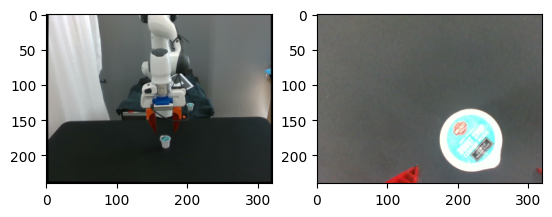

In [20]:
plt.subplot(121)
plt.imshow(agentview_rgb[:,:,::-1])
plt.subplot(122)
plt.imshow(eye_in_hand_rgb[:,:,::-1])

In [34]:
def get_current_obs(robot_interface):
    last_state = robot_interface._state_buffer[-1]
    # print(last_state)
    last_gripper_state = robot_interface._gripper_state_buffer[-1]
    
    obs_dict = raw_obs_dict_generator.get_raw_obs_dict(
    {"last_state": last_state, "last_gripper_state": last_gripper_state})
    # obs_dict={} #rgb only 

    data = get_imgs()
    img_wrist = data['camera_0_color']
    img_front = data['camera_1_color']

    agentview_rgb=img_wrist
    eye_in_hand_rgb=img_front
    # agentview_rgb=cv2.resize(img_wrist, (120, 160))  
    # eye_in_hand_rgb=cv2.resize(img_front, (120, 160)) 
    agentview_rgb = cv2.resize(img_wrist, None, fx=0.5, fy=0.5)
    eye_in_hand_rgb = cv2.resize(img_front, None, fx=0.5, fy=0.5)

    # agentview_rgb.shape, eye_in_hand_rgb.shape

    obs_dict['agentview_rgb']=agentview_rgb #.transpose(2, 1, 0)
    obs_dict['eye_in_hand_rgb']=eye_in_hand_rgb #.transpose(2, 1, 0)
    return obs_dict

In [35]:
obs_dict=get_current_obs(robot_interface)
for key in obs_dict.keys():
    obs_dict[key]=obs_dict[key][None]
    print(key, obs_dict[key].shape)

ee_states (1, 16)
joint_states (1, 7)
gripper_states (1, 1)
agentview_rgb (1, 120, 160, 3)
eye_in_hand_rgb (1, 120, 160, 3)


In [36]:
obs_dict=get_current_obs(robot_interface)
for key in obs_dict.keys(): 
    print(key, obs_dict[key].shape)

ee_states (16,)
joint_states (7,)
gripper_states (1,)
agentview_rgb (120, 160, 3)
eye_in_hand_rgb (120, 160, 3)


In [37]:
request_data = franka_policy.make_franka_example()
request_data['prompt'] = 'pick up the coffee pod'
request_data.keys()

for key in request_data.keys():
    if key not in ["prompt"]:
        print(f"key={key} shape={request_data[key].shape} dtype={request_data[key].dtype}")

key=observation/image shape=(120, 160, 3) dtype=uint8
key=observation/wrist_image shape=(120, 160, 3) dtype=uint8
key=observation/joint_position shape=(7,) dtype=float64
key=observation/gripper_position shape=(1,) dtype=float64


In [41]:
obs_dict=get_current_obs(robot_interface)

request_data={}
request_data['prompt']='pick up the coffee pod'
request_data['observation/image'] = obs_dict['agentview_rgb']
request_data['observation/wrist_image'] = obs_dict['eye_in_hand_rgb']
request_data['observation/joint_position'] = obs_dict['joint_states']
request_data['observation/gripper_position'] = obs_dict['gripper_states']

# Wrap the server call in a context manager to prevent Ctrl+C from interrupting it
# Ctrl+C will be handled after the server call is complete
with prevent_keyboard_interrupt():
    # this returns action chunk [10, 8] of 10 joint velocity actions (7) + gripper position (1)
    pred_action_chunk = policy_client.infer(request_data)["actions"]

In [42]:
pred_action_chunk.shape

(10, 7)

In [62]:
reset_joints_to(robot_interface, reset_joint_positions)
set_gripper(open=True)

JOINT_POSITION
passed1
pre
done pre
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
pre
done pre


In [61]:
images = []
for _ in range(500):
    # action, grasp = input2action(
    #     device=spacemouse,
    #     controller_type=controller_type,
    # )
    # if action is None:
    #     break
    if len(robot_interface._state_buffer) == 0:
        continue

    obs_dict=get_current_obs(robot_interface)
    imgs1=obs_dict['agentview_rgb']
    imgs2=obs_dict['eye_in_hand_rgb']
    img=np.concatenate([imgs1, imgs2], axis=1) 
    images.append(img)


    request_data={}
    request_data['prompt']='pick up the coffee pod'
    request_data['observation/image'] = obs_dict['agentview_rgb']
    request_data['observation/wrist_image'] = obs_dict['eye_in_hand_rgb']
    request_data['observation/joint_position'] = obs_dict['joint_states']
    request_data['observation/gripper_position'] = obs_dict['gripper_states']

    # Wrap the server call in a context manager to prevent Ctrl+C from interrupting it
    # Ctrl+C will be handled after the server call is complete
    with prevent_keyboard_interrupt():
        # this returns action chunk [10, 8] of 10 joint velocity actions (7) + gripper position (1)
        pred_action_chunk = policy_client.infer(request_data)["actions"]


    for action in pred_action_chunk[:1]:  
        robot_interface.control(
            controller_type=controller_type,
            action=action,
            controller_cfg=controller_cfg,
        )

    # time.sleep(0.045)

    
robot_interface.close()

passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1
passed1


KeyboardInterrupt: 

In [63]:
import imageio 
from datetime import datetime

now = datetime.now().strftime("%Y-%m-%d_%H_%M")
savepath = f"inference_videos/{now}_pod_pi.mp4"

print('saving video to: ', savepath)

writer = imageio.get_writer(savepath, fps=3)
for img in images:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
    writer.append_data(img)
writer.close()

saving video to:  inference_videos/2025-07-16_10_34_pod_pi.mp4


In [46]:
img.shape

(3, 320, 120)

In [52]:
obs_dict=get_current_obs(robot_interface)
imgs1=obs_dict['agentview_rgb']
imgs2=obs_dict['eye_in_hand_rgb']
img=np.concatenate([imgs1, imgs2], axis=1) 
img.shape

(120, 320, 3)